In [9]:
import os

target_path = '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/092_data/092_labels.json'
source_root = '/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data/092_data/origin_data'

In [10]:
os.listdir(source_root)

['[라벨]EMOIMG_중립_TRAIN',
 '[라벨]EMOIMG_중립_VALID',
 '[원천]EMOIMG_중립_TRAIN_01',
 '[원천]EMOIMG_중립_TRAIN_02',
 '[원천]EMOIMG_중립_TRAIN_03',
 '[원천]EMOIMG_중립_TRAIN_04',
 '[원천]EMOIMG_중립_VALID']

In [11]:
import json
import re
'''
wrinkle json 포맷:
  {
    "user_id": "F0008_IND_F_56",
    "filename": "F0008_IND_F_56_0_02.JPG",
    "forehead_path": "",
    "right_eye_path": "045_data/data/right_eye_F0008_IND_F_56_0_02.JPG",
    "left_eye_path": "045_data/data/left_eye_F0008_IND_F_56_0_02.JPG",
    "nasolabial_path": "045_data/data/nasolabial_F0008_IND_F_56_0_02.JPG",
    "perioral_path": "045_data/data/perioral_F0008_IND_F_56_0_02.JPG",
    "right_vol_path": "045_data/data/right_vol_F0008_IND_F_56_0_02.JPG",
    "left_vol_path": "045_data/data/left_vol_F0008_IND_F_56_0_02.JPG",
  },
'''
json_data = []

names = [name for name in os.listdir(source_root) if name.startswith('[라벨]')]
os.listdir(os.path.join(source_root, names[0]))
for name in names:
    target_jsons = os.listdir(os.path.join(source_root, name))
    for target_json in target_jsons:
        target_path = os.path.join(source_root, name, target_json)
        with open(target_path, 'r') as f:
            for data in json.load(f):
                json_data.append({
                    'user_id': re.search(r".*_.{1}_[0-9]+", data['filename']).group(),
                    'filename': data['filename'],
                })
        print(len(json_data))

59233
66636


In [12]:
import random

sample = random.sample(json_data, 1)[0]
sample

{'user_id': 'fa08024e594250c4ae606525a9faef57d39c279f7c2356bfe922437a6858cdf7_남_20',
 'filename': 'fa08024e594250c4ae606525a9faef57d39c279f7c2356bfe922437a6858cdf7_남_20_중립_도심 환경_20210122160241-008-001.jpg'}

In [13]:
filenames = []

for data in json_data:
    filenames.append(data['filename'])

#### preprocess

In [ ]:
import sys
sys.path.append('/home/work/hocheol_dir/workspace/_dataset')
from utils.Mediapipe import MediaPipe
from preprocess.remove_non_skin import remove_non_skin
sys.path.append('/home/work/hocheol_dir/workspace/_dataset/preprocess/wrinkle/v0.3/v0.3.0')
from wrinkle_preprocess import wrinkle_preprocess
from worker import process_wrinkle_image2, initializer
from utils.constants import SECTORS

import os
from PIL import Image
from multiprocessing import get_context, current_process

2025-11-05 19:44:57.109407: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-05 19:44:57.168588: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-05 19:44:57.168647: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-05 19:44:57.170257: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-05 19:44:57.180443: I tensorflow/core/platform/cpu_feature_guar

In [8]:
from tqdm import tqdm

try:
    with get_context('spawn').Pool(processes=4, initializer=initializer) as pool:
        results = list(tqdm(pool.imap_unordered(process_wrinkle_image2, filenames), total=len(filenames)))
    success_count = sum(1 for r in results if r.startswith('success'))
    failure_count = len(results) - success_count

    fail_list = [r for r in results if r.startswith('failed')]
except Exception as e:
    print(f"An error occurred during multiprocessing: {str(e)}")

with open('/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3.0/092_test_data/label/wrinkle_test.json', 'w') as f:
    json.dump(json_data, f, indent=2, ensure_ascii=False)

  0%|                                                                                                                                                                      | 0/66636 [00:00<?, ?it/s]

2025-11-05 19:45:34.692676: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-05 19:45:34.692727: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-05 19:45:34.694305: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-05 19:45:34.738142: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-05 19:45:34.738188: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factor

Initializing MediaPipe for process: SpawnPoolWorker-5


I0000 00:00:1762339540.981785  821881 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL
W0000 00:00:1762339540.982833  821881 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1762339540.995852  822141 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1762339541.019942  822139 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Initializing MediaPipe for process: SpawnPoolWorker-6
Initializing MediaPipe for process: SpawnPoolWorker-8
Initializing MediaPipe for process: SpawnPoolWorker-7


I0000 00:00:1762339541.187309  821882 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL
W0000 00:00:1762339541.188582  821882 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1762339541.199591  822153 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1762339541.208160  821884 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL
W0000 00:00:1762339541.209142  821884 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1762339541.219754  822160 inference_feedback_man

KeyboardInterrupt: 

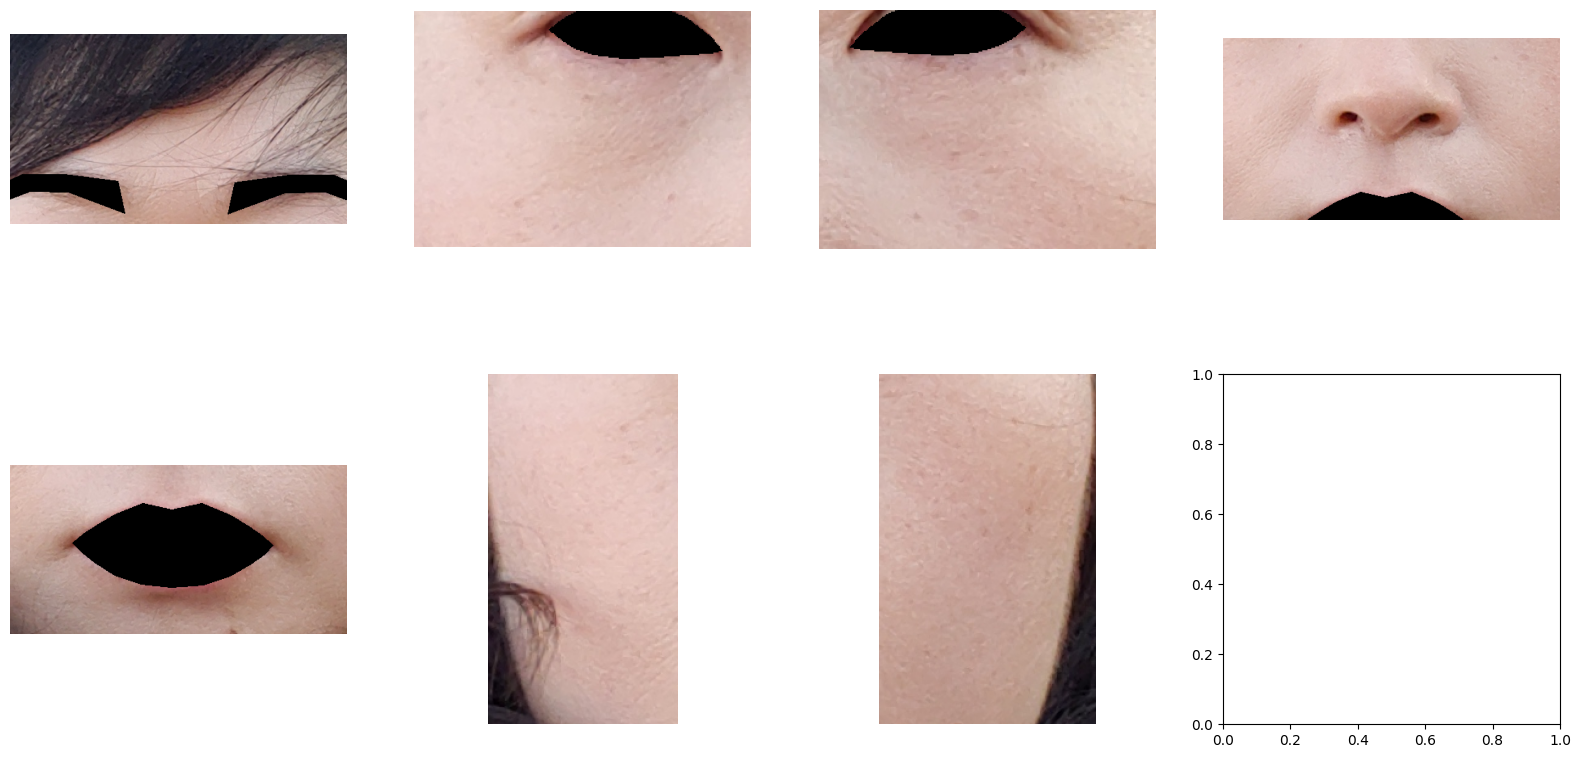

In [104]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

for i, img in enumerate([forehead, right_eye, left_eye, nasolabial, oral, right_cheek, left_cheek]):
    ax[i//4, i%4].imshow(img)
    ax[i//4, i%4].axis('off')

plt.show()

In [8]:
json_data[0]

{'user_id': '6e941deb878a4582d63d66e8013e26fdca94a935ade338448300c52c7453db52_여_40',
 'filename': '6e941deb878a4582d63d66e8013e26fdca94a935ade338448300c52c7453db52_여_40_중립_실외 자연환경_20210224191319-007-004.jpg'}

#### labeling

In [14]:
%cd /home/work/hocheol_dir/workspace

/home/work/hocheol_dir/workspace


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
from utils.constants import SECTORS
from tqdm import tqdm

wrinkle_root = '/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3_data'

for data in tqdm(json_data):
    # print(data)
    for sector in SECTORS:
        file_path = os.path.join(wrinkle_root, '092_data', 'test_data', f"{sector}_{data['filename']}")
        if os.path.exists(file_path):
            data[f'{sector}_path'] = file_path
        else:
            data[f'{sector}_path'] = ''
        data[f"{sector}"] = -1

with open('/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3.0/092_test_data/label/wrinkle_test.json', 'w') as f:
    json.dump(json_data, f, indent=2, ensure_ascii=False)

2025-11-07 10:58:16.320191: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-07 10:58:16.378654: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-07 10:58:16.378702: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-07 10:58:16.380363: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-07 10:58:16.392534: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
from tqdm import tqdm

pig_root = '/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4_data'

for data in tqdm(json_data):
    for sector in SECTORS:
        if f"{sector}_path" in data:
            del data[f"{sector}_path"]
        if f"{sector}" in data:
            del data[f"{sector}"]

    # print(data)
    for sector in ['left', 'right']:
        file_path = os.path.join(pig_root, '092_data', 'test_data', f"{sector}_{data['filename']}")
        if os.path.exists(file_path):
            data[f'{sector}_path'] = file_path
        else:
            data[f'{sector}_path'] = ''
        data[f"{sector}_label"] = -1

with open('/home/work/hocheol_dir/workspace/_dataset/datasets/pigment_data/v0.4/v0.4.1/092_test_data/label/pig_test.json', 'w') as f:
    json.dump(json_data, f, indent=2, ensure_ascii=False)

100%|██████████| 66636/66636 [00:51<00:00, 1303.32it/s]
